## Topic

Train / Validation / Test Split

先读[Machine Learning Foundations](../Study%20topics/ml-foundations-start-here.html)，再读对应[双语讲义](../Study%20topics/train-validation-test-split.html)。

## Question

What roles do training, validation and test sets play?

本实验中的模型或评估方法是什么？它解决什么问题，又怎样检验效果？

讲义提供Key Terms、直观例子、英文Short Answer及紧接其后的中文回答。先理解问题，再运行下面的代码。


# Train / Validation / Test Split

## Learning Goal

I fit parameters on training data, choose configurations on validation data, and reserve the test set for the final estimate. Repeatedly checking test results turns the test set into another validation set.

## Minimal Prerequisites

Basic Python arrays and functions. Run all cells in order; no API key or network data is required. Data are synthetic teaching fixtures, not empirical market evidence.

## Guided Experiment

Change the random seed and validation fraction. Compare score variability across three synthetic datasets: clean linear, noisy linear, and nonlinear. Explain why a random split is only appropriate for independent observations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


clean train/validation/test sizes 180 60 60 validation MAE 0.15310070484237628
noisy train/validation/test sizes 180 60 60 validation MAE 2.2915415660905234
nonlinear train/validation/test sizes 180 60 60 validation MAE 4.348525004216743


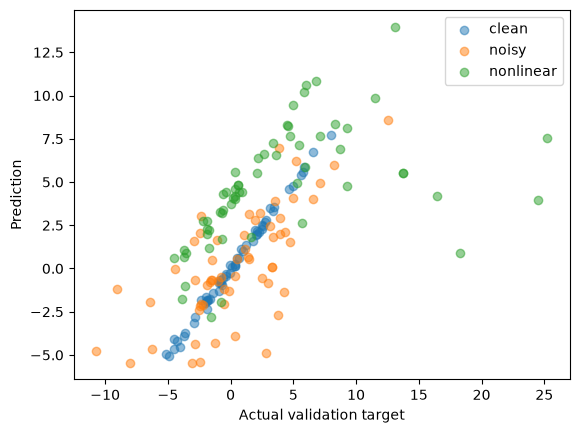

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
seed = 7
for name, noise, nonlinear in [("clean", .2, False), ("noisy", 3., False), ("nonlinear", .2, True)]:
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(300, 3)); y = X[:,0]*3 + noise*rng.normal(size=300)
    if nonlinear: y += 5*X[:,1]**2
    train, remaining = train_test_split(np.arange(300), test_size=.4, random_state=seed)
    valid, test = train_test_split(remaining, test_size=.5, random_state=seed)
    assert not (set(train)&set(valid) or set(train)&set(test) or set(valid)&set(test))
    model = Ridge().fit(X[train], y[train])
    print(name, "train/validation/test sizes", len(train), len(valid), len(test), "validation MAE", mean_absolute_error(y[valid], model.predict(X[valid])))
    plt.scatter(y[valid], model.predict(X[valid]), alpha=.5, label=name)
plt.xlabel("Actual validation target"); plt.ylabel("Prediction"); plt.legend(); plt.show()

## Expected Observations

Higher noise raises irreducible error. A linear model cannot capture the quadratic effect simply by changing the split. Test targets are deliberately not scored here.

## Review Experiment

Before changing a parameter, write the direction you expect and why. Change only the parameter named in the guided experiment; rerun from a fresh kernel. Compare the observed result with your prediction. On a later review day, explain the code without reading the answers.

## English Check Questions

1. What quantity is this experiment estimating?
2. What information is available at prediction time?
3. Which observation would invalidate your conclusion?

## Reference Answers

1. I fit parameters on training data, choose configurations on validation data, and reserve the test set for the final estimate. Repeatedly checking test results turns the test set into another validation set.
2. Training inputs and their labels must be available before the relevant evaluation origin; preprocessing is fitted on training data only.
3. Higher noise raises irreducible error. A linear model cannot capture the quadratic effect simply by changing the split. Test targets are deliberately not scored here.

## Financial Connection

Transfer the timing, metric or deployment contract to the five-day volatility Workbench. A toy experiment verifies mechanics, not trading profitability.

## Sources

- https://scikit-learn.org/stable/common_pitfalls.html
- https://scikit-learn.org/stable/modules/cross_validation.html
- https://scikit-learn.org/stable/modules/model_evaluation.html

[Return to study page](../Study%20topics/train-validation-test-split.html)
